In [1]:
from datasets import load_from_disk
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

In [2]:
dataset = load_from_disk("../data/eurosat")
class_names = dataset["train"].features["label"].names

print(dataset)
print(f"\nClasses: {class_names}")

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 16200
    })
    test: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 5400
    })
    validation: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 5400
    })
})

Classes: ['Annual Crop', 'Forest', 'Herbaceous Vegetation', 'Highway', 'Industrial Buildings', 'Pasture', 'Permanent Crop', 'Residential Buildings', 'River', 'SeaLake']


In [3]:
# Confirm how many images are in each split
for split in ["train", "validation", "test"]:
    print(f"  {split:<12} → {len(dataset[split]):,} images")

  train        → 16,200 images
  validation   → 5,400 images
  test         → 5,400 images


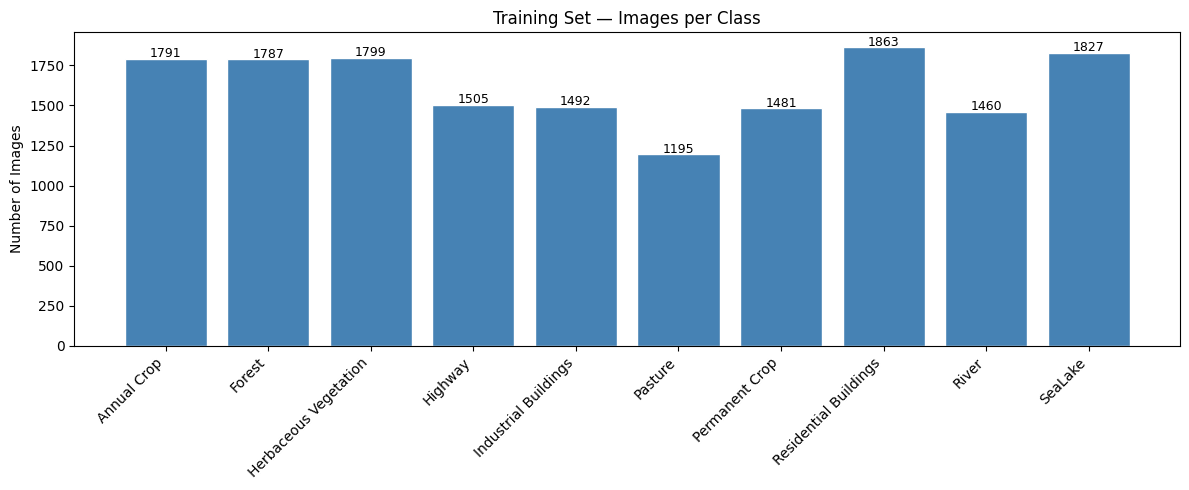

Saved to results/class_distribution.png


In [4]:
# Visualize how many images exist per class in the training set
# Balanced = good! All bars should be roughly equal height
label_counts = Counter(dataset["train"]["label"])
counts = [label_counts[i] for i in range(len(class_names))]

plt.figure(figsize=(12, 5))
bars = plt.bar(class_names, counts, color="steelblue", edgecolor="white")
plt.xticks(rotation=45, ha="right")
plt.title("Training Set — Images per Class")
plt.ylabel("Number of Images")
plt.tight_layout()

# Annotate each bar with its count
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 10,
             str(count), ha="center", fontsize=9)

plt.savefig("../results/class_distribution.png", dpi=150)
plt.show()
print("Saved to results/class_distribution.png")

Pasture has fewer images than Residential Buildings — the model may struggle slightly more with Pasture

Overall the imbalance is mild, so it won't cause serious problems

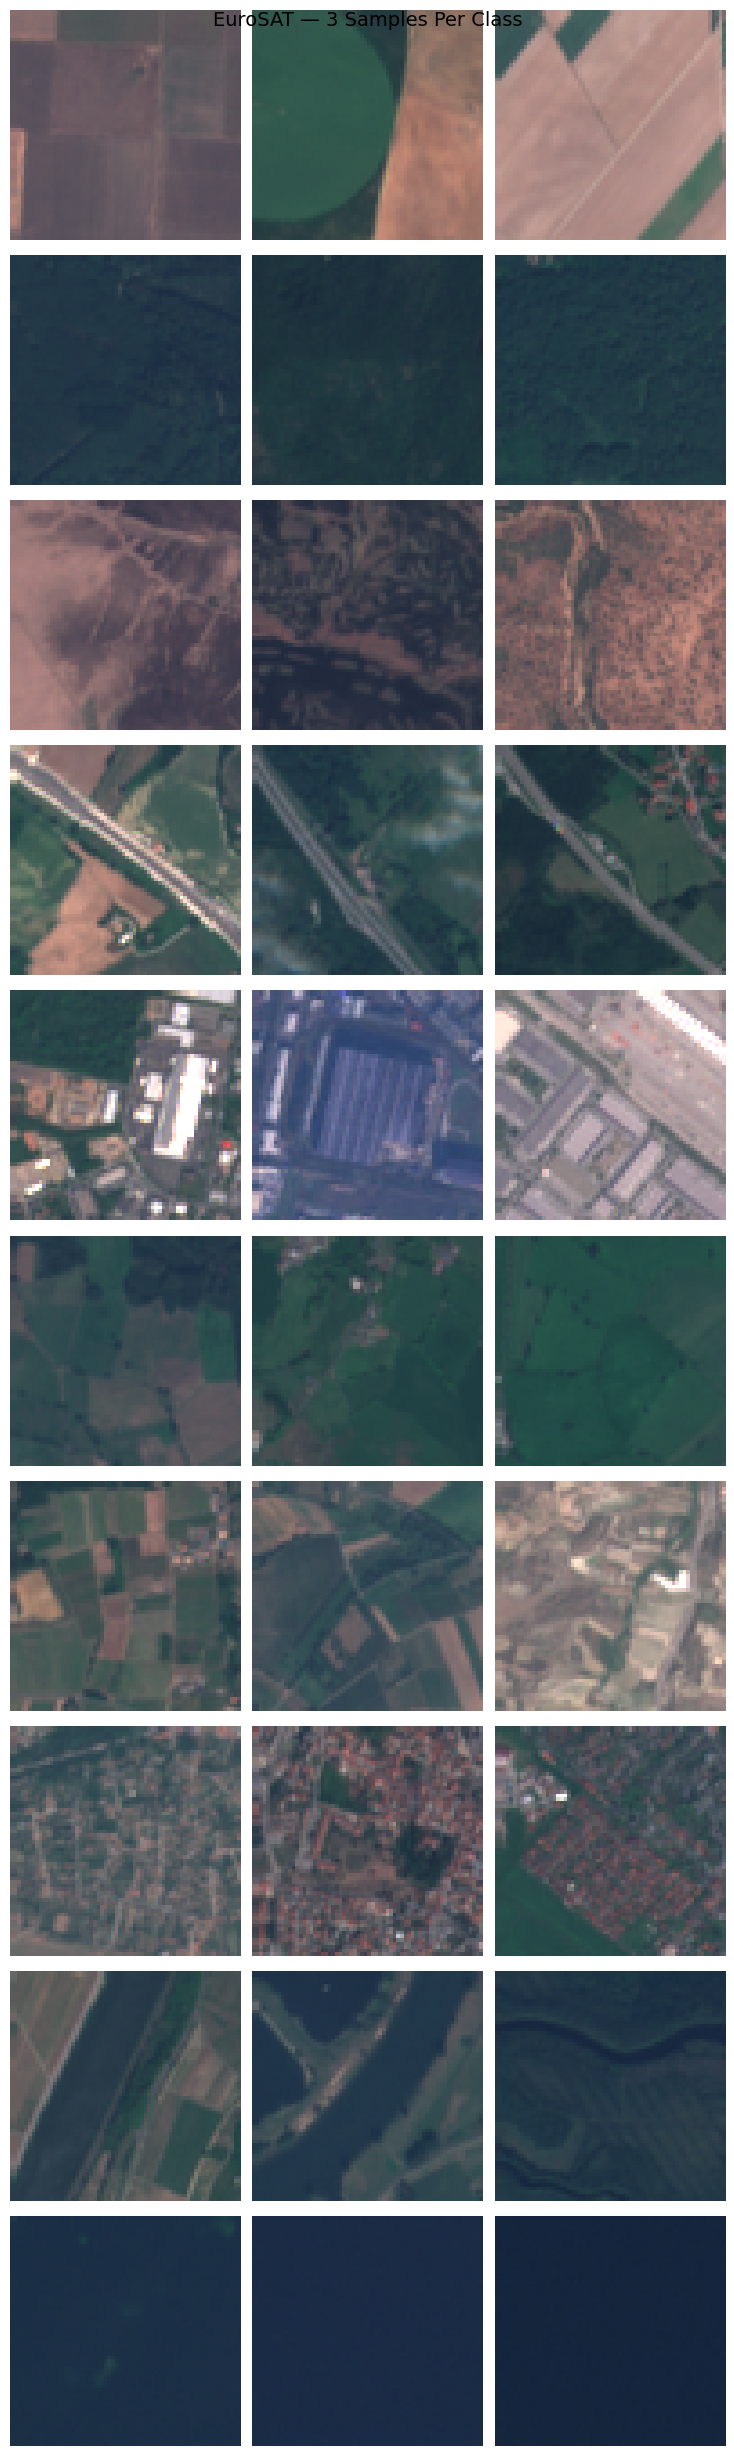

Saved to results/samples_per_class.png


In [11]:
# Multiple samples per class

# Show 3 samples per class to understand visual variety within each category
n_samples = 3
fig, axes = plt.subplots(len(class_names), n_samples,
                         figsize=(n_samples * 2.5, len(class_names) * 2.5))
fig.suptitle("EuroSAT — 3 Samples Per Class", fontsize=14)

# Collect 3 samples per class by scanning the dataset once
samples = {i: [] for i in range(len(class_names))}
for sample in dataset["train"]:
    label = sample["label"]
    if len(samples[label]) < n_samples:
        samples[label].append(sample["image"])
    if all(len(v) == n_samples for v in samples.values()):
        break

for label_id, row_axes in enumerate(axes):
    for i, ax in enumerate(row_axes):
        ax.imshow(samples[label_id][i])
        ax.axis("off")
        if i == 0:
            ax.set_ylabel(class_names[label_id], fontsize=9, rotation=0,
                          labelpad=60, va="center")

plt.tight_layout()
plt.savefig("../results/samples_per_class.png", dpi=150)
plt.show()
print("Saved to results/samples_per_class.png")

In [7]:
# Image properties

# Check image size, format, and pixel value range
# ViT expects 224x224 images — resize during preprocessing

sample_image = dataset["train"][0]["image"]
img_array = np.array(sample_image)

print(f"Image mode:        {sample_image.mode}")   # Should be RGB
print(f"Image size:        {sample_image.size}")   # Width x Height
print(f"Array shape:       {img_array.shape}")     # Height x Width x Channels
print(f"Pixel value range: {img_array.min()} – {img_array.max()}")
print(f"Data type:         {img_array.dtype}")

Image mode:        RGB
Image size:        (64, 64)
Array shape:       (64, 64, 3)
Pixel value range: 75 – 195
Data type:         uint8


64×64 → 224×224 (Upscaling)

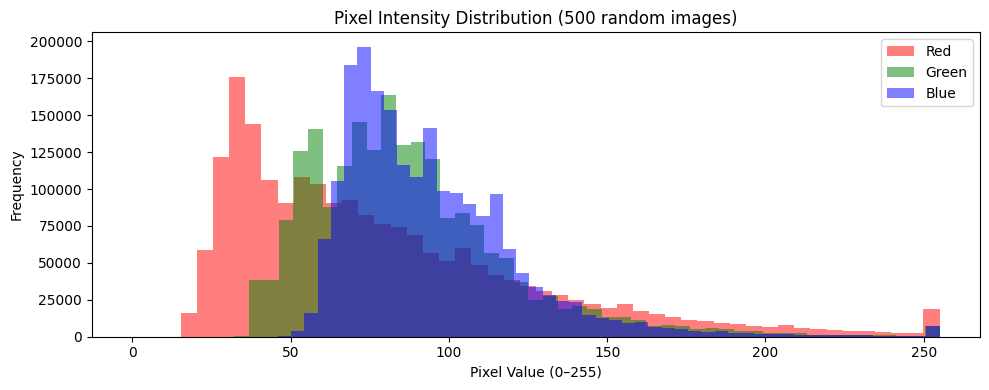

Saved to results/pixel_distribution.png


In [8]:
# Plot the RGB channel intensity distribution across a sample of images
# This tells us if images are dark, bright, or well-balanced
n_sample = 500  # Use 500 random images for speed
indices = np.random.choice(len(dataset["train"]), n_sample, replace=False)

r_vals, g_vals, b_vals = [], [], []
for idx in indices:
    img = np.array(dataset["train"][int(idx)]["image"])
    r_vals.extend(img[:, :, 0].flatten())
    g_vals.extend(img[:, :, 1].flatten())
    b_vals.extend(img[:, :, 2].flatten())

plt.figure(figsize=(10, 4))
plt.hist(r_vals, bins=50, color="red",   alpha=0.5, label="Red")
plt.hist(g_vals, bins=50, color="green", alpha=0.5, label="Green")
plt.hist(b_vals, bins=50, color="blue",  alpha=0.5, label="Blue")
plt.title("Pixel Intensity Distribution (500 random images)")
plt.xlabel("Pixel Value (0–255)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("../results/pixel_distribution.png", dpi=150)
plt.show()
print("Saved to results/pixel_distribution.png")

In [10]:
print("=" * 40)
print("EXPLORATION COMPLETE")
print("=" * 40)
print(f"  Image size:        64x64 px (RGB)")
print(f"  Classes:           {len(class_names)}")
print(f"  Train images:      {len(dataset['train']):,}")
print(f"  Validation images: {len(dataset['validation']):,}")
print(f"  Test images:       {len(dataset['test']):,}")
print(f"  Saved charts to:   ../results/")
print("=" * 40)

EXPLORATION COMPLETE
  Image size:        64x64 px (RGB)
  Classes:           10
  Train images:      16,200
  Validation images: 5,400
  Test images:       5,400
  Saved charts to:   ../results/
